In [1]:
# Copyright 2022 Google LLC
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# 운영 및 데이터 AI 혁신: Operational AI Leap (Zero ETL)

**"The Operational AI Leap: Zero ETL for Operational AI"** 라이브 실행 실습 노트북에 오신 것을 환영합니다!

---

## 데이터 사이언티스트 및 엔지니어 여러분을 환영합니다! (Zero ETL이란?)

Google Cloud를 처음 접하시거나 기존 데이터 아키텍처에 익숙하신 분들은 **기존 ETL의 딜레마(Traditional ETL Dilemma)** 를 잘 알고 계실 것입니다:
기존 아키텍처에서는 데이터 사이언티스트와 ML 엔지니어가 트랜잭션 데이터베이스 테이블을 별도의 분석용 데이터 레이크로 복사하기 위해 복잡한 **ETL(Extract, Transform, Load)** 파이프라인이 완료될 때까지 며칠 또는 몇 주를 기다려야 합니다. 이러한 분절된 방식은 높은 지연 시간(Latency)과 인프라 비용을 초래하며, 결국 최신성이 떨어지는 과거 데이터로 모델링할 수밖에 없게 만듭니다.

**Zero ETL for Operational AI** 는 패러다임을 바꿉니다: 외부 ML 도구로 데이터를 추출하는 대신, **AI 모델과 분석 엔진을 운영 트랜잭션 데이터베이스 내부로 직접 가져옵니다** .

### 실제 사용자 시나리오 (페르소나)
*Cymbal Shops*의 수석 데이터 사이언티스트 **Abby** 를 소개합니다. Abby는 실시간 재고, 시맨틱 유사도, 과거 구매 트렌드를 기반으로 상품을 추천하는 엔터프라이즈급 AI 쇼핑 어시스턴트를 구축해야 합니다. **AlloyDB for PostgreSQL** 과 **Google Colab Enterprise** 를 활용함으로써, Abby는 단 하나의 ETL 복제 스크립트도 작성하지 않고 몇 시간 만에 전체 추천 파이프라인을 배포합니다.

---

## 아키텍처 플로우 다이어그램
아래는 Colab Enterprise 및 Google Cloud 데이터 레이크와 연결된 3계층 AlloyDB 아키텍처(`AI Extension Layer`, `Operational Schema`, `Query Planner`)의 전체 구성도입니다:

<p align="center">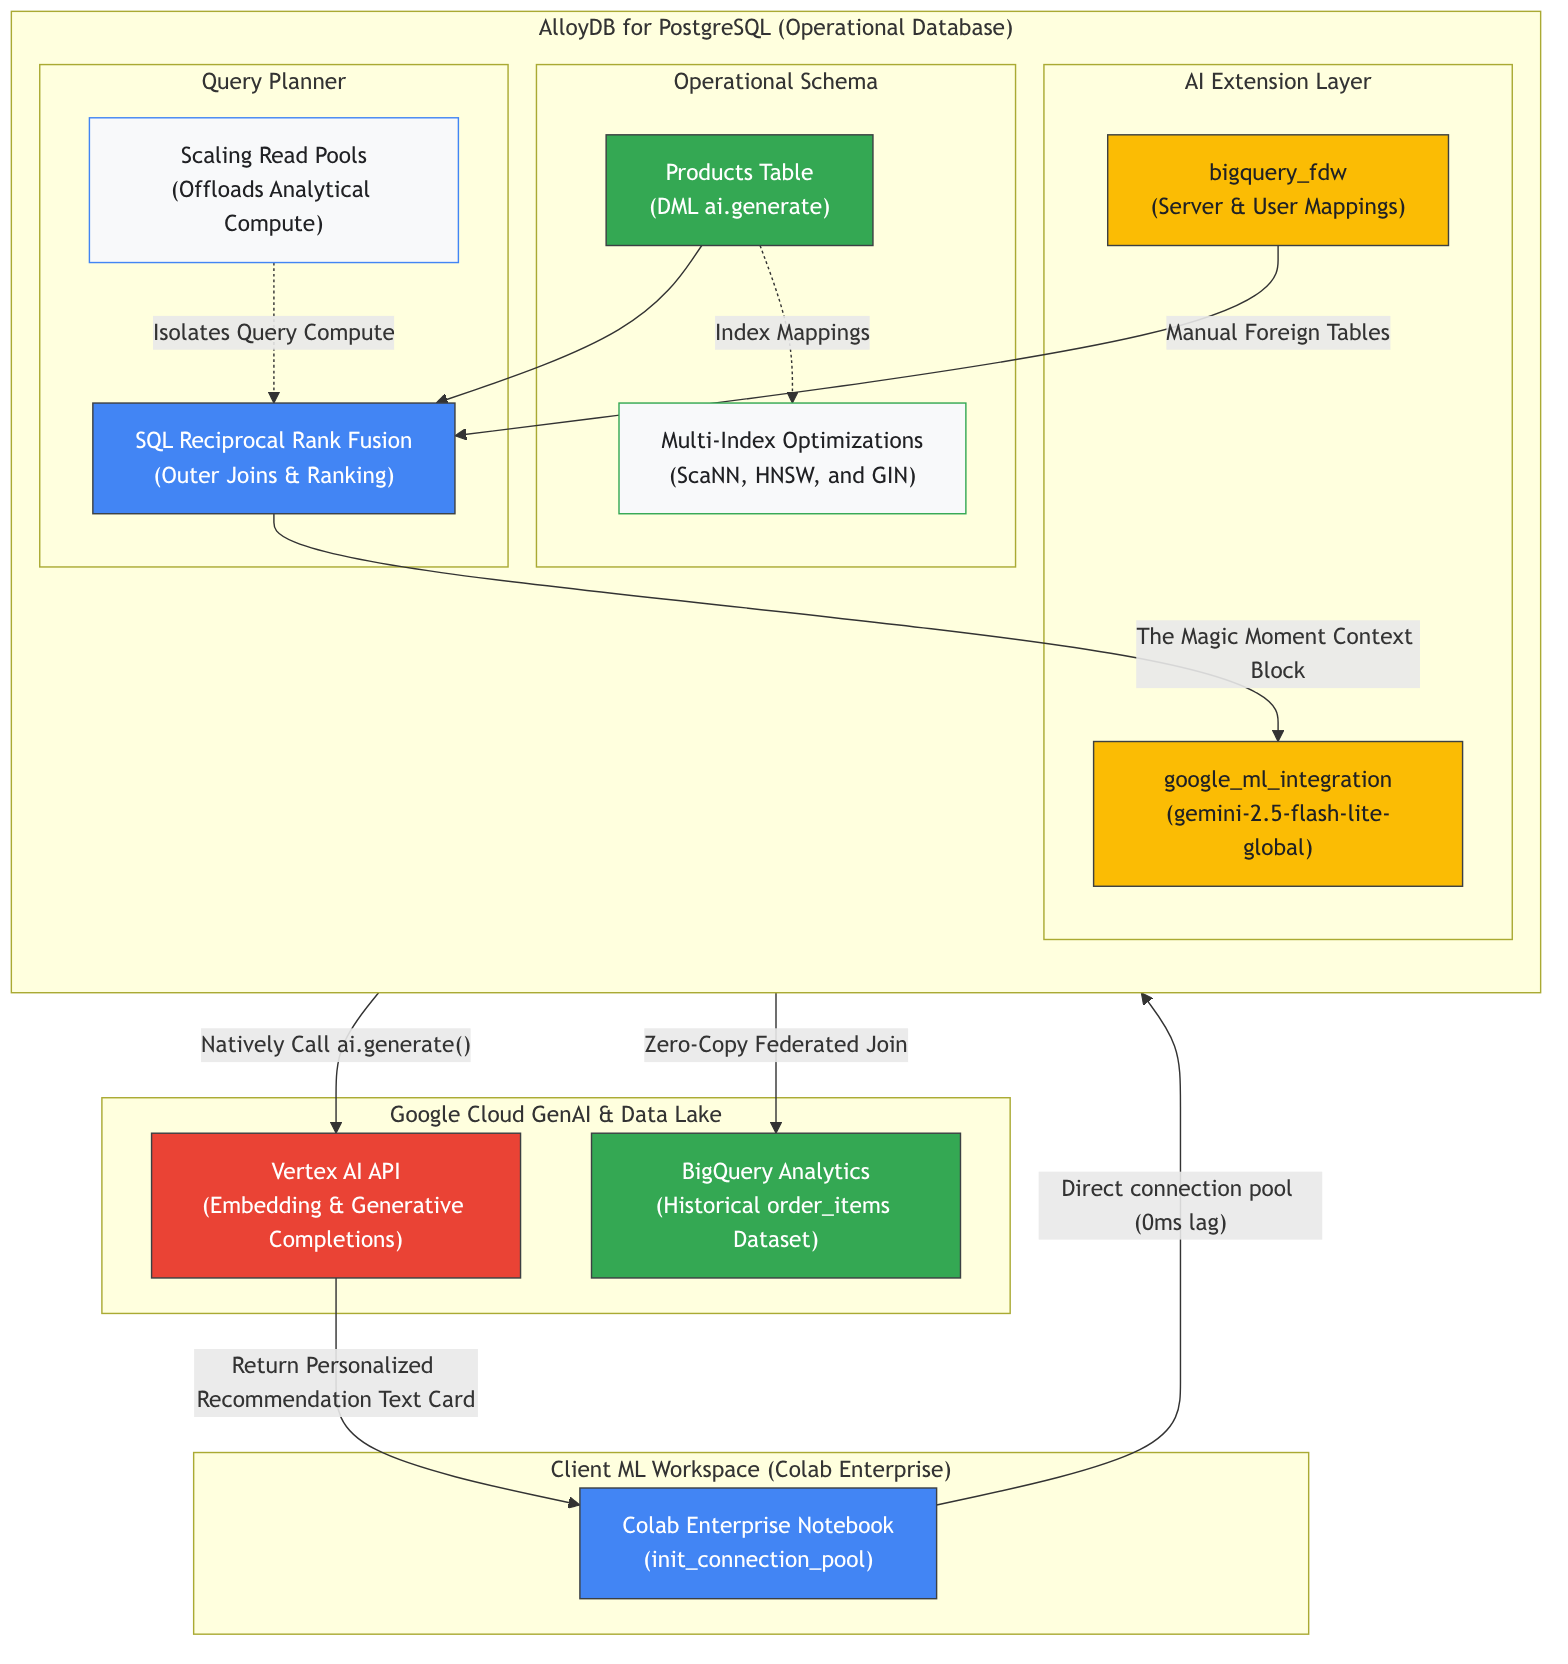</p>

---

## 본 노트북의 주요 학습 목표

- **Zero-ETL 아키텍처:** Colab Enterprise를 `0ms` 복제 지연 시간의 실시간 AlloyDB 운영 테이블에 직접 연결합니다.
- **데이터베이스 내장 생성형 AI:** `google_ml.create_model()` 및 `ai.generate()`를 사용하여 SQL 내부에서 Vertex AI Gemini 모델을 직접 호출합니다.
- **멀티 인덱스 최적화:** Dense Vector 시맨틱 유사도(`ScaNN`), Full-Text 키워드 검색(`GIN`), Sparse(`BM25`) 인덱스를 결합한 하이브리드 검색을 수행합니다.
- **Reciprocal Rank Fusion (RRF):** PostgreSQL 실행 커널 내부에서 다양한 검색 신호를 결합하고 재정렬(Re-ranking)합니다.
- **레이크하우스 페더레이션 (`bigquery_fdw`):** 페타바이트 규모의 데이터를 이동하지 않고 과거 BigQuery 데이터 레이크와 Zero-Copy SQL 조인을 수행합니다.

---

## 사전 준비사항 (Prerequisites)
사전 프로비저닝된 Qwiklabs 환경 외부에서 본 노트북을 실행하는 경우, 먼저 [README.md](https://github.com/GoogleCloudPlatform/cloud-solutions/blob/main/projects/operational-ai-leap/README.md)에 따라 기본 인프라를 배포해야 합니다.


## 연결 설정 및 환경 구성 (Connection Setup & Environment Configuration)

`uv` 명령어를 사용하여 필요한 Python 패키지를 설치합니다.


In [ ]:
# 필요한 Python 패키지 설치
! uv pip install \
    asyncpg \
    google-auth \
    google-cloud-aiplatform \
    google-cloud-alloydb-connector \
    google-cloud-storage \
    google-genai \
    ipykernel \
    jupyter-server \
    pandas \
    pillow \
    pymilvus-model \
    requests \
    sqlalchemy \
    tenacity \
    greenlet \
    python-dotenv

현재 사용 중인 AlloyDB 및 Google Cloud 프로젝트 구성에 맞게 연결 변수를 정의합니다.

> **Note for Qwiklabs Students** : You can find your exact `project_id` and `alloydb_password` right in the **Qwiklabs UI** under the **Student Visible Outputs** panel on the left side where you started this lab! (Qwiklabs 실습생 안내: 실습을 시작한 왼쪽의 **Student Visible Outputs** 패널에서 정확한 `project_id` 및 `alloydb_password`를 확인할 수 있습니다!)


In [ ]:
# 본인의 실습 환경 설정에 맞게 아래 변수를 업데이트하세요
# Qwiklabs 실습생 안내: 실습을 시작한 왼쪽의 'Student Visible Outputs' 패널에서 정확한 project_id와 alloydb_password를 확인할 수 있습니다!
project_id = "your-project-id"  # @param {type:"string"}
region = "us-central1"  # @param {type:"string"}
alloydb_cluster = "stylesearch-cluster"  # @param {type:"string"}
alloydb_instance = "stylesearch-instance"  # @param {type:"string"}
alloydb_database = "ecom"  # @param {type:"string"}
alloydb_password = "your-db-password"  # @param {type:"string"}

Google Cloud AlloyDB Connector를 사용하여 SQL 연결 풀(Connection pool)을 초기화하고, 비동기 쿼리를 실행하는 헬퍼 함수(`run_query`)를 정의합니다.


In [ ]:
import asyncio
import logging

import asyncpg
import pandas as pd
import sqlalchemy
from google.cloud.alloydb.connector import AsyncConnector, IPTypes
from sqlalchemy import exc, text
from sqlalchemy.ext.asyncio import AsyncEngine, create_async_engine

# Configure basic logging
logging.basicConfig(level=logging.WARNING)

# Initialize SQL connection pool using Google Cloud AlloyDB Connector


async def init_connection_pool(
    connector: AsyncConnector, db_name: str, pool_size: int = 5
) -> AsyncEngine:
    connection_string = f"projects/{project_id}/locations/{region}/clusters/{alloydb_cluster}/instances/{alloydb_instance}"

    async def getconn() -> asyncpg.Connection:
        conn: asyncpg.Connection = await connector.connect(
            connection_string,
            "asyncpg",
            user="postgres",
            password=alloydb_password,
            db=db_name,
            ip_type=IPTypes.PRIVATE,
        )
        return conn

    pool = create_async_engine(
        "postgresql+asyncpg://",
        async_creator=getconn,
        pool_size=pool_size,
        max_overflow=0,
        isolation_level="AUTOCOMMIT",
    )
    return pool


# Updated query execution helper to capture PostgreSQL RAISE NOTICE statements in real-time


async def run_query(pool, sql: str, params=None, output_as_df: bool = True):
    sql_lower_stripped = sql.strip().lower()
    is_select_with = sql_lower_stripped.startswith(("select", "with"))
    is_explain = sql_lower_stripped.startswith("explain")
    is_data_returning = is_select_with or is_explain
    effective_output_as_df = output_as_df and is_select_with
    is_bulk_operation = (
        isinstance(params, (list, tuple))
        and len(params) > 0
        and isinstance(params[0], (dict, tuple, list))
    )

    def handle_notice(connection, message):
        print(f"{message.severity}: {message.message}")

    async with pool.connect() as conn:
        raw_conn = await conn.get_raw_connection()
        driver_conn = getattr(raw_conn, "driver_connection", None)

        has_listener = driver_conn is not None and hasattr(
            driver_conn, "add_log_listener"
        )
        if has_listener:
            driver_conn.add_log_listener(handle_notice)

        try:
            if params:
                result = await conn.execute(text(sql), params)
            else:
                result = await conn.execute(text(sql))

            if is_data_returning:
                if is_explain:
                    try:
                        plan_rows = result.fetchall()
                        query_plan = "\n".join(
                            [str(row[0]) for row in plan_rows]
                        )
                        return query_plan
                    except Exception as e:
                        logging.error(f"Error fetching EXPLAIN: {e}")
                        return None
                else:
                    if effective_output_as_df:
                        try:
                            rows = result.fetchall()
                            column_names = result.keys()
                            return pd.DataFrame(rows, columns=column_names)
                        except Exception as e:
                            logging.error(f"Error converting DataFrame: {e}")
                            return result
                    else:
                        return result
            else:
                await conn.commit()
                operation_type = sql.strip().split()[0].upper()
                row_count = result.rowcount
                if is_bulk_operation:
                    print(
                        f"Bulk {operation_type} executed. Result rowcount: {row_count}"
                    )
                else:
                    print(
                        f"{operation_type} executed. {row_count} row(s) affected."
                    )
                return result

        except exc.ProgrammingError as e:
            logging.error(f"SQL Error: {e}")
            return None
        except Exception as e:
            logging.error(f"Unexpected Error: {e}")
            raise
        finally:
            if has_listener:
                try:
                    driver_conn.remove_log_listener(handle_notice)
                except Exception:
                    pass


# Create connector and connection pools
connector = AsyncConnector()
ecom_db_pool = await init_connection_pool(connector, alloydb_database)
print("Connection pool to live AlloyDB database established successfully.")

## Step 1: 데이터 사일로 해소 (실시간 직접 쿼리)

### 본 코드 블록의 역할
저지연 Python 연결 풀(`asyncpg`)을 사용하여 **AlloyDB for PostgreSQL** 내부의 핵심 트랜잭션 테이블(`products`)에 비동기 SQL 쿼리를 직접 실행합니다. 실시간 행(Row) 수, 디스크상의 테이블 크기, 샘플 활성 카탈로그 레코드를 조회합니다.

### 왜 필요한가요?
기존 데이터 사이언스 워크플로에서 분석가는 무거운 쿼리가 고객 트랜잭션을 지연시킬 위험이 있기 때문에 운영 데이터베이스를 직접 쿼리할 수 없습니다. 대신 야간 CSV 덤프나 ETL 동기화를 기다려야 합니다. AlloyDB의 클라우드 네이티브 아키텍처는 데이터 사이언티스트가 **0ms 지연 시간** 으로 실시간 트랜잭션 레코드를 안전하게 쿼리할 수 있도록 지원합니다.

### 실제 시나리오 예시
*데이터 사이언티스트 Abby*는 시즌별 카탈로그 업데이트가 배포된 직후 고객 상품 추천 모델을 검증하고자 합니다. ETL 작업이 새 재고를 데이터 레이크로 동기화할 때까지 24시간을 기다리는 대신, Abby는 Colab Enterprise 노트북 내에서 실시간 레코드를 즉시 확인합니다.

---
아래 셀을 실행하여 Step 1 데이터 흐름을 확인하고 실시간 테이블 메트릭을 조회해 보세요!

<p align="center">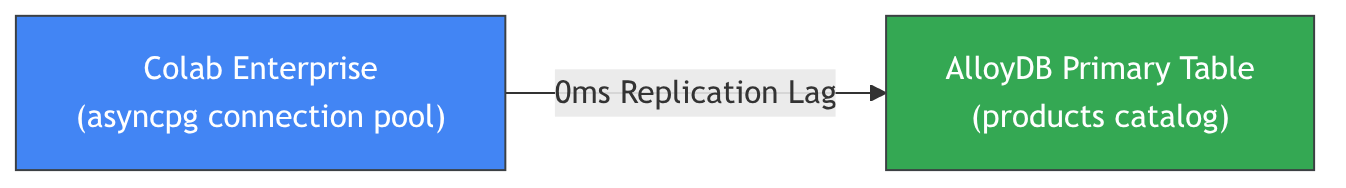</p>


In [ ]:
# 실시간 테이블 행(Row) 수 및 스토리지 크기 정보 조회
sql_metrics = """
SELECT 'products' AS table_name,
       COUNT(*) AS row_count,
       pg_size_pretty(pg_relation_size('products')) AS table_size
FROM products;
"""
metrics_df = await run_query(ecom_db_pool, sql_metrics)
display(metrics_df)

In [ ]:
# 실시간 상품 레코드 샘플 조회
sql_sample = """
SELECT id, name, brand, category, retail_price
FROM products
LIMIT 1000;
"""
sample_df = await run_query(ecom_db_pool, sql_sample)
display(sample_df)

### 💡 실습 도전과제 (Challenge 1): 실시간 상품 카탈로그 필터링 및 집계

**미션:** 실시간 `products` 테이블에서 'Apparel & Accessories' 카테고리 중 가격(`retail_price`)이 가장 높은 상위 5개 상품을 조회하는 SQL 쿼리를 작성하세요.

> 💡 **힌트가 필요하신가요?** 도전과제를 해결하다가 막히는 경우, 본 노트북의 맨 마지막에 있는 **도전과제 힌트 및 솔루션 가이드 (Challenge Tips & Hints)** 섹션에서 추천 SQL 쿼리 팁을 확인할 수 있습니다!


In [ ]:
# =====================================================================
# CHALLENGE 1: 실시간 상품 카탈로그 필터링 및 집계
# =====================================================================
# 미션: 실시간 `products` 테이블에서 'Apparel & Accessories' 카테고리 중 가격(`retail_price`)이 가장 높은 상위 5개 상품을 조회하는 SQL 쿼리를 작성하세요.
#
# =====================================================================

sql_challenge_1 = """
-- [여기에 직접 작성한 SQL 쿼리를 입력하세요]
"""

# 아래 주석을 해제(# 제거)한 후 셀을 실행하여 작성한 쿼리 결과를 확인하세요:
# await run_query(sql_challenge_1)


## Step 2: AI 네이티브 모델 매핑 및 벡터 기능

### 본 코드 블록의 역할
이 섹션에서는 `google_ml_integration` 데이터베이스 확장 프로그램을 사용하여 AlloyDB가 Google Cloud의 **Vertex AI** 플랫폼과 기본적으로 통합되는 방법을 안내합니다. 다음 4가지 핵심 SQL 기능을 검증합니다:
1. **모델 등록 (Model Registration)** : PostgreSQL 내부에 원격 Vertex AI 엔드포인트를 등록합니다 (`CALL google_ml.create_model(...)`).
2. **모델 카탈로그 뷰 (Model Catalog View)** : `google_ml.model_info_view` 시스템 뷰에서 등록된 모델 목록을 확인합니다.
3. **데이터베이스 내장 임베딩 (In-Database Embeddings)** : `embedding('gemini-embedding-model', text)`을 호출하여 SQL 내부에서 문자열을 768차원 벡터 임베딩으로 변환합니다.
4. **데이터베이스 내장 생성형 AI (In-Database Generative AI)** : `ai.generate('gemini-model', prompt)`를 호출하여 데이터베이스 쿼리에서 직접 사람과 같은 텍스트 요약 및 응답을 생성합니다.

### 왜 필요한가요?
일반적으로 임베딩이나 LLM 응답을 생성하려면 네트워크를 통해 행을 조회하고, 외부 ML 서비스로 API 호출을 하나씩 전송한 뒤, 그 결과를 다시 저장하는 복잡한 클라이언트 스크립트를 작성해야 합니다. `ai.generate()` 및 `embedding()`을 SQL 내부에 기본 내장함으로써, 데이터베이스 엔진이 API 인증, 배치 처리, 실행을 자체적으로 제어합니다.

### 실제 시나리오 예시
*상품 자동 분류*. 공급업체가 데이터베이스에 신규 상품을 추가하면, AlloyDB SQL 쿼리가 외부 Python 백엔드 서비스 없이도 해당 상품의 벡터 임베딩을 자동으로 계산하고 Gemini를 호출하여 카테고리를 분류합니다.

---
아래 셀을 실행하여 데이터베이스 내장 추론 시퀀스를 확인하고 SQL 네이티브 임베딩 및 텍스트 생성을 테스트해 보세요!

<p align="center">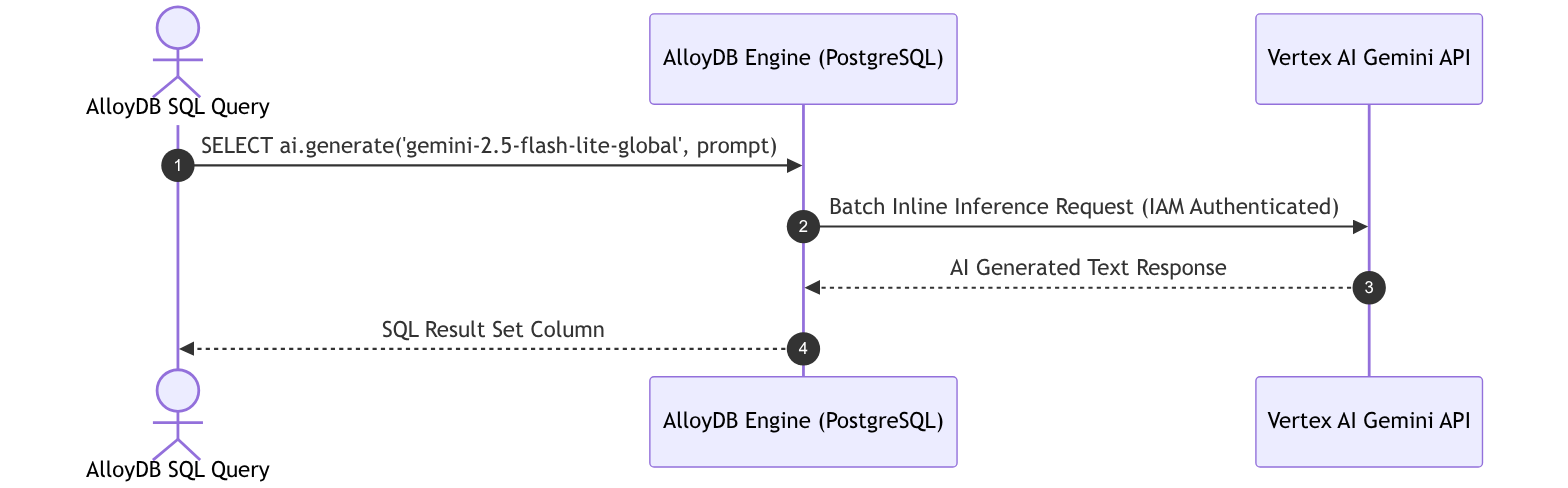</p>


In [ ]:
sql_create_model = f"""
CALL
  google_ml.create_model(
    model_id => 'gemini-2.5-flash-lite-global',
    model_type => 'llm',
    model_provider => 'google',
    model_qualified_name => 'gemini-2.5-flash-lite',
    model_request_url =>  'https://aiplatform.googleapis.com/v1/projects/{project_id}/locations/global/publishers/google/models/gemini-2.5-flash-lite:generateContent',
    model_auth_type => 'alloydb_service_agent_iam'
);
"""
await run_query(ecom_db_pool, sql_create_model)

In [ ]:
# 1. 데이터베이스 내부에 등록된 모델 엔드포인트 조회
sql_models = """
SELECT model_id, model_qualified_name, model_type, model_availability
FROM google_ml.model_info_view
WHERE model_availability = 'USER_REGISTERED';"""
models_df = await run_query(ecom_db_pool, sql_models)
display(models_df)

In [ ]:
# 2. AlloyDB 내부에서 SQL 네이티브 임베딩 생성 실행
sql_embed = """
SELECT embedding('gemini-embedding-001',
'AlloyDB AI provides Zero-ETL embeddings') AS vector_sample;
"""
embed_df = await run_query(ecom_db_pool, sql_embed)
display(embed_df)
print(
    f"Successfully generated text embedding vector. Dimensions: {len(embed_df['vector_sample'].iloc[0])}"
)

In [ ]:
# 3. 등록된 Gemini 엔드포인트를 사용하여 직접 SQL 텍스트 생성 실행
sql_gen = """
SELECT
ai.generate('Say hello from database-native SQL!',
model_id => 'gemini-2.5-flash-lite-global') AS response;
"""
gen_df = await run_query(ecom_db_pool, sql_gen)
display(gen_df)

### 💡 실습 도전과제 (Challenge 2): SQL 내부 임베딩 생성 및 LLM 프롬프팅

**미션:** `ai.generate('gemini-model', prompt)`를 호출하여 'Sunglasses' 카테고리 상품들에 대한 1줄짜리 소셜 미디어 홍보 문구를 PostgreSQL 내부에서 직접 생성하는 SQL 쿼리를 작성하세요.

> 💡 **힌트가 필요하신가요?** 도전과제를 해결하다가 막히는 경우, 본 노트북의 맨 마지막에 있는 **도전과제 힌트 및 솔루션 가이드 (Challenge Tips & Hints)** 섹션에서 추천 SQL 쿼리 팁을 확인할 수 있습니다!


In [ ]:
# =====================================================================
# CHALLENGE 2: SQL 내부 임베딩 생성 및 LLM 프롬프팅
# =====================================================================
# 미션: `ai.generate('gemini-model', prompt)`를 호출하여 'Sunglasses' 카테고리 상품들에 대한 1줄짜리 소셜 미디어 홍보 문구를 PostgreSQL 내부에서 직접 생성하는 SQL 쿼리를 작성하세요.
#
# =====================================================================

sql_challenge_2 = """
-- [여기에 직접 작성한 SQL 쿼리를 입력하세요]
"""

# 아래 주석을 해제(# 제거)한 후 셀을 실행하여 작성한 쿼리 결과를 확인하세요:
# await run_query(sql_challenge_2)


## Step 3: 데이터베이스 내장 생성 기능 확인

### 본 코드 블록의 역할
`products` 테이블을 쿼리하여 `product_description` 열을 조회합니다. 이 열은 선언적 SQL 배치 업데이트(`UPDATE products SET product_description = ai.generate(...)`)를 통해 채워졌으며, Gemini가 구매 전환율을 높이는 마케팅 문구를 운영 테이블 레코드에 직접 작성했습니다.

### 왜 필요한가요?
생성형 AI를 활용한 피처 엔지니어링(Feature engineering)이 선언적 SQL로 간소화됩니다. 데이터베이스 행을 확장하기 위해 메모리를 초과하는 Python 데이터프레임이나 복잡한 Celery/Airflow 워커를 관리하는 대신, 데이터베이스 내부에서 안정적으로 작동하는 표준 SQL `UPDATE` 문을 실행할 수 있습니다.

### 실제 시나리오 예시
*카탈로그 대량 보강*. 유통 상품 기획 팀이 `"BLK HOODIE L"`과 같이 짧은 명칭만 포함된 50,000개의 원시 공급업체 SKU를 임포트합니다. 예약된 단 하나의 SQL 쿼리가 Gemini를 사용하여 단 몇 분 만에 모든 상품에 대한 매력적이고 SEO에 최적화된 상세 설명을 생성합니다.

---
아래 셀을 실행하여 상품 카탈로그에 저장된 AI 생성 카피라이팅을 확인해 보세요!


In [ ]:
# 새롭게 생성 및 저장된 상품 상세 설명(product_description) 열 조회
sql_desc = """
SELECT id, name, category, product_description
FROM products
WHERE product_description IS NOT NULL
LIMIT 1000;
"""
desc_df = await run_query(ecom_db_pool, sql_desc)
display(desc_df)

### 💡 실습 도전과제 (Challenge 3): AI 생성 마케팅 설명 분석 및 키워드 검색

**미션:** Gemini가 생성 및 저장한 `product_description` 열에서 'lightweight' 또는 'comfortable'이라는 단어가 포함된 상품을 찾아 상위 5개를 반환하는 SQL 쿼리를 작성하세요.

> 💡 **힌트가 필요하신가요?** 도전과제를 해결하다가 막히는 경우, 본 노트북의 맨 마지막에 있는 **도전과제 힌트 및 솔루션 가이드 (Challenge Tips & Hints)** 섹션에서 추천 SQL 쿼리 팁을 확인할 수 있습니다!


In [ ]:
# =====================================================================
# CHALLENGE 3: AI 생성 마케팅 설명 분석 및 키워드 검색
# =====================================================================
# 미션: Gemini가 생성 및 저장한 `product_description` 열에서 'lightweight' 또는 'comfortable'이라는 단어가 포함된 상품을 찾아 상위 5개를 반환하는 SQL 쿼리를 작성하세요.
#
# =====================================================================

sql_challenge_3 = """
-- [여기에 직접 작성한 SQL 쿼리를 입력하세요]
"""

# 아래 주석을 해제(# 제거)한 후 셀을 실행하여 작성한 쿼리 결과를 확인하세요:
# await run_query(sql_challenge_3)


## Step 4: 개별 검색 모델 쿼리

### 본 코드 블록의 역할
동일한 상품 테이블에 대해 두 가지 별도의 검색 전략을 실행합니다:
1. **Dense Vector 검색 (ScaNN / pgvector)** : 코사인 거리(`<=>`) 연산자를 사용하여 `"silver sunglasses"`의 의미론적(Semantic) 의미를 상품 임베딩과 비교합니다.
2. **Full-Text 키워드 검색 (GIN / `ts_rank`)** : `"silver"` 및 `"sunglasses"`의 정확한 토큰 일치 및 어간(Stemming)을 검색합니다.

### 왜 필요한가요?
최신 추천 엔진에는 **하이브리드 검색(Hybrid Search)** 이 필수적입니다. 순수 키워드 검색은 사용자가 동의어를 사용할 때 실패합니다(예: `"shades"`로 검색하면 `"sunglasses"`를 놓침). 반면 순수 벡터 검색은 정확한 부품 번호나 브랜드 이름을 놓칠 수 있습니다(예: `"Ray-Ban RB3025"`). 개별 인덱스를 각각 테스트함으로써 두 방식을 결합해야 하는 이유를 확인할 수 있습니다.

### 실제 시나리오 예시
*쇼핑몰 검색창*. 고객이 `"silver sunglasses"`를 검색합니다. Dense Vector 검색은 시각적 콘셉트가 유사한 세련된 메탈 프레임을 찾아내고, 키워드 검색은 `"silver"` 태그가 명시적으로 지정된 상품이 상단에 노출되도록 보장합니다.

---
아래 셀을 실행하여 이중 검색 전략 다이어그램을 확인하고 Dense 시맨틱 검색과 Full-Text 키워드 검색을 비교해 보세요!

<p align="center">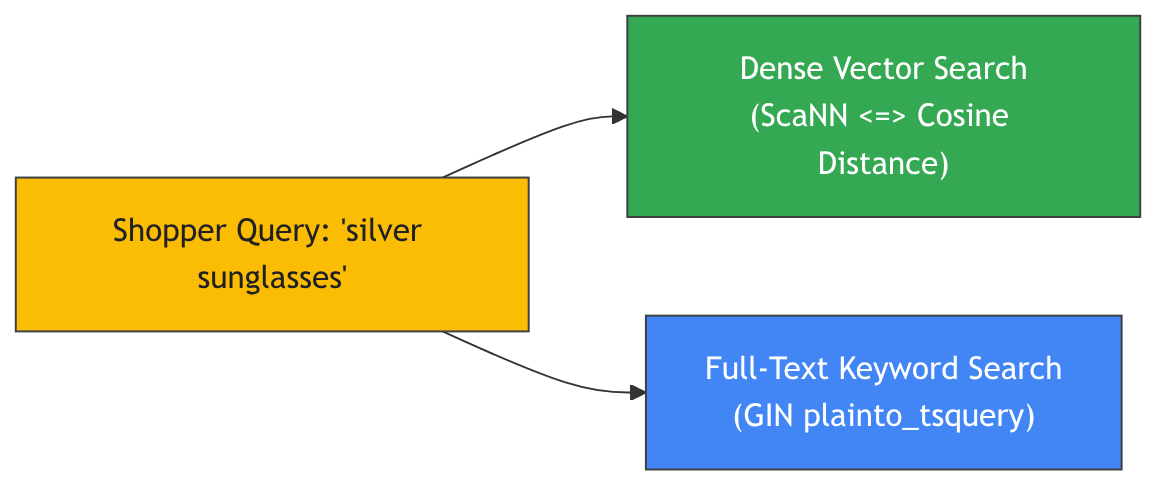</p>


In [ ]:
query_term = "silver sunglasses"

# 1. Dense Vector 코사인 유사도 검색 실행
sql_dense = f"""
SELECT id, name, brand, retail_price,
       product_embedding <=> embedding('gemini-embedding-001',
       '{query_term}')::vector AS distance
FROM products
ORDER BY distance ASC
LIMIT 1000;
"""
print("--- Dense Vector 시맨틱 검색 결과 ---")
dense_results = await run_query(ecom_db_pool, sql_dense)
display(dense_results)

In [ ]:
# 2. 가중치가 적용된 PostgreSQL Full-Text 키워드 검색 실행
sql_fts = f"""
SELECT id, name,
ts_rank(fts_document, plainto_tsquery('english', '{query_term}')) AS rank_score
FROM products
WHERE fts_document @@ plainto_tsquery('english', '{query_term}')
ORDER BY rank_score DESC
LIMIT 1000;
"""
print("\n--- PostgreSQL Full-Text Search Results ---")
fts_results = await run_query(ecom_db_pool, sql_fts)
display(fts_results)

### 💡 실습 도전과제 (Challenge 4): Dense Vector 시맨틱 검색 직접 테스트

**미션:** 'cozy winter wool sweater'나 'waterproof hiking boots'와 같은 새로운 검색어에 대해 `<=>` 코사인 거리 연산자를 활용한 Dense Vector 유사도 검색 SQL 쿼리를 직접 작성해 보세요.

> 💡 **힌트가 필요하신가요?** 도전과제를 해결하다가 막히는 경우, 본 노트북의 맨 마지막에 있는 **도전과제 힌트 및 솔루션 가이드 (Challenge Tips & Hints)** 섹션에서 추천 SQL 쿼리 팁을 확인할 수 있습니다!


In [ ]:
# =====================================================================
# CHALLENGE 4: Dense Vector 시맨틱 검색 직접 테스트
# =====================================================================
# 미션: 'cozy winter wool sweater'나 'waterproof hiking boots'와 같은 새로운 검색어에 대해 `<=>` 코사인 거리 연산자를 활용한 Dense Vector 유사도 검색 SQL 쿼리를 직접 작성해 보세요.
#
# =====================================================================

sql_challenge_4 = """
-- [여기에 직접 작성한 SQL 쿼리를 입력하세요]
"""

# 아래 주석을 해제(# 제거)한 후 셀을 실행하여 작성한 쿼리 결과를 확인하세요:
# await run_query(sql_challenge_4)


## Step 5: SQL 내 Reciprocal Rank Fusion (RRF)

### 본 코드 블록의 역할
정확한 SKU 일치, Full-Text 키워드 검색, Sparse BM25 순위, Dense Vector 유사도라는 4가지 독립적인 검색 신호를 **Reciprocal Rank Fusion(RRF)** 공식(`1.0 / (60 + rank)`)을 사용하여 단일 SQL 쿼리로 결합합니다.

### 왜 필요한가요?
기존 하이브리드 검색 아키텍처에서는 별도의 벡터 데이터베이스와 검색 엔진에서 수천 개의 후보를 애플리케이션 메모리(Python)로 추출하여 통합 순위 점수를 계산해야 합니다. AlloyDB는 멀티 인덱스 스캔, RRF 점수 계산 및 정렬을 PostgreSQL 쿼리 실행 커널 내부에서 1 밀리초 미만의 속도로 직접 처리합니다!

### 실제 시나리오 예시
*지능형 검색 재정렬 (Re-Ranking)*. 고객이 검색어를 입력하면, AlloyDB가 개념적 유사도, 정확한 키워드 일치, 관계형 재고 제약 조건을 단 한 번의 데이터베이스 왕복(Round-trip)으로 즉시 균형 있게 조합합니다.

---
아래 셀을 실행하여 RRF 점수 산출 다이어그램을 확인하고 SQL 내부에서 네이티브로 실행되는 Reciprocal Rank Fusion을 경험해 보세요!

<p align="center">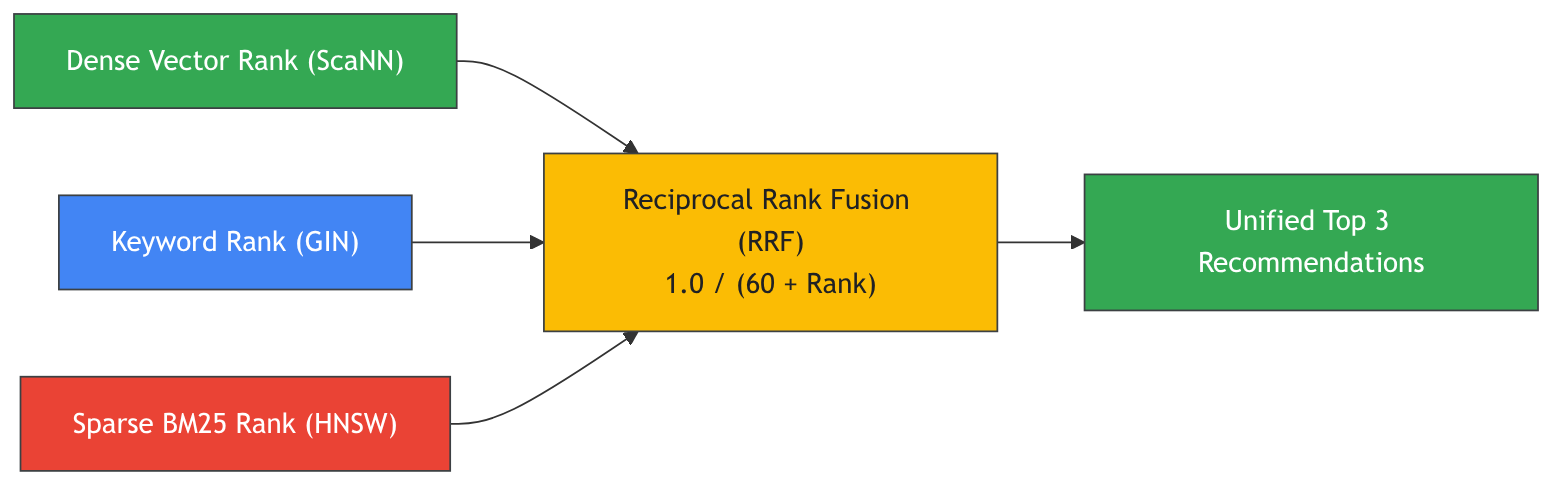</p>


In [ ]:
# 표준 테스트 환경에는 피팅된 BM25 파라미터도 포함되어 있습니다. 통합 RRF 쿼리를 실행해 봅시다.
query_term = "silver sunglasses"
mock_sparse = "{2:3.5}/46696"

sql_rrf = f"""
WITH fts_search AS (
  SELECT id, name, ts_rank(fts_document, plainto_tsquery('english', '{query_term}')) AS fts_score,
         RANK() OVER (ORDER BY ts_rank(fts_document, plainto_tsquery('english', '{query_term}')) DESC) as fts_rank
  FROM products WHERE fts_document @@ plainto_tsquery('english', '{query_term}') LIMIT 1000
),
bm25_search AS (
  SELECT id, name, sparse_embedding <#> '{mock_sparse}'::sparsevec AS bm25_dist,
         RANK() OVER (ORDER BY sparse_embedding <#> '{mock_sparse}'::sparsevec) AS bm25_rank
  FROM products WHERE sparse_embedding <#> '{mock_sparse}'::sparsevec < 1 LIMIT 1000
),
vector_search AS (
  SELECT id, name, product_embedding <=> embedding('gemini-embedding-001', '{query_term}')::vector AS distance,
         RANK() OVER (ORDER BY product_embedding <=> embedding('gemini-embedding-001', '{query_term}')::vector) AS vector_rank
  FROM products LIMIT 1000
)
SELECT
  COALESCE(v.id, f.id, b.id) AS id,
  COALESCE(v.name, f.name, b.name) AS name,
  (COALESCE(1.0 / (60 + v.vector_rank), 0.0) +
   COALESCE(1.0 / (60 + f.fts_rank), 0.0) +
   COALESCE(1.0 / (60 + b.bm25_rank), 0.0)) AS rrf_score
FROM vector_search v
FULL OUTER JOIN fts_search f ON v.id = f.id
FULL OUTER JOIN bm25_search b ON COALESCE(v.id, f.id) = b.id
ORDER BY rrf_score DESC LIMIT 1000;
"""
rrf_df = await run_query(ecom_db_pool, sql_rrf)
display(rrf_df)

### 💡 실습 도전과제 (Challenge 5): Reciprocal Rank Fusion (RRF) 민감도 튜닝

**미션:** 'silver sunglasses' 쿼리에 대한 RRF 점수 산출 CTE에서 RRF 스무딩 상수(`60`)를 `15`로 변경하거나 `vector_score`에 `2.0`을 곱하여 통합 순위가 어떻게 변하는지 실험해 보세요.

> 💡 **힌트가 필요하신가요?** 도전과제를 해결하다가 막히는 경우, 본 노트북의 맨 마지막에 있는 **도전과제 힌트 및 솔루션 가이드 (Challenge Tips & Hints)** 섹션에서 추천 SQL 쿼리 팁을 확인할 수 있습니다!


In [ ]:
# =====================================================================
# CHALLENGE 5: Reciprocal Rank Fusion (RRF) 민감도 튜닝
# =====================================================================
# 미션: 'silver sunglasses' 쿼리에 대한 RRF 점수 산출 CTE에서 RRF 스무딩 상수(`60`)를 `15`로 변경하거나 `vector_score`에 `2.0`을 곱하여 통합 순위가 어떻게 변하는지 실험해 보세요.
#
# =====================================================================

sql_challenge_5 = """
-- [여기에 직접 작성한 SQL 쿼리를 입력하세요]
"""

# 아래 주석을 해제(# 제거)한 후 셀을 실행하여 작성한 쿼리 결과를 확인하세요:
# await run_query(sql_challenge_5)


## Step 6: 레이크하우스 조인 및 즉각적인 SQL 추론 (The Magic Moment)

### 본 섹션의 역할
운영 데이터베이스에서 트랜잭션이 발생할 때마다 **AlloyDB의 고속 트랜잭션 엔진** 과 **BigQuery의 대규모 데이터 레이크** 를 **ETL 파이프라인 없이** 조인하고, 그 결과를 즉시 **Gemini 생성형 AI** 로 전달하여 고객을 위한 맞춤형 추천 카드를 생성하는 'Magic Moment'를 구성합니다.

---

`bigquery_fdw` (BigQuery Foreign Data Wrapper)를 통해 AlloyDB에서 BigQuery 데이터 레이크를 직접 조회할 수 있도록 AlloyDB 서비스 계정에 필요한 IAM 권한을 구성합니다.


`bigquery_fdw` (BigQuery Foreign Data Wrapper)를 통해 AlloyDB에서 BigQuery 데이터 레이크를 직접 조회할 수 있도록 AlloyDB 서비스 계정에 필요한 IAM 권한을 구성합니다.


In [ ]:
# AlloyDB 클러스터가 사용하는 서비스 계정 확인
alloydb_serviceaccount =! gcloud beta alloydb clusters describe {alloydb_cluster} \
    --region={region} \
    --project={project_id} \
    --format="value(serviceAccountEmail)"
alloydb_serviceaccount = alloydb_serviceaccount[0]
print(f"alloydb_serviceaccount = {alloydb_serviceaccount}")

In [ ]:
# AlloyDB에서 BigQuery에 접근하기 위해 필요한 IAM 권한 목록
roles_array = [
    "roles/bigquery.dataViewer",
    "roles/bigquery.readSessionUser",
    "roles/bigquery.jobUser",
    "roles/storage.objectViewer",
]

# Add IAM Roles to the Alloy DB service account
for r in roles_array:
  ! gcloud projects add-iam-policy-binding {project_id} \
      --member="serviceAccount:{alloydb_serviceaccount}" \
      --role="{r}" \
      --no-user-output-enabled

In [ ]:
# AlloyDB 서비스 계정에 할당된 IAM 권한 목록 조회
sa_roles = ! gcloud projects get-iam-policy {project_id} \
  --flatten="bindings[].members" \
  --filter="bindings.members:serviceAccount:{alloydb_serviceaccount}" \
  --format="value(bindings.role)"

for r in sa_roles:
  if r in roles_array:
    print(r)

AlloyDB 클러스터에 `bigquery_fdw.enabled` 데이터베이스 플래그가 활성화되어 있는지 검증합니다 (Terraform에 의해 이미 활성화됨).


In [ ]:
# AlloyDB 클러스터의 데이터베이스 플래그 설정 확인
! gcloud beta alloydb instances describe {alloydb_instance} \
    --region={region} \
    --cluster={alloydb_cluster} \
    --format="value(databaseFlags)"

`bigquery_fdw` 확장 프로그램을 생성합니다.


In [ ]:
sql = "CREATE EXTENSION IF NOT EXISTS bigquery_fdw"
await run_query(ecom_db_pool, sql)

원격 BigQuery 데이터셋에 대한 연결 매개변수를 정의하는 외부 서버(Foreign Server)를 생성합니다.


In [ ]:
sql_array = []
sql_array.append("DROP SERVER IF EXISTS bq_server CASCADE")
sql_array.append("CREATE SERVER bq_server FOREIGN DATA WRAPPER bigquery_fdw")

for sql in sql_array:
    await run_query(ecom_db_pool, sql)

로컬 PostgreSQL 사용자(`postgres`)를 외부 서버의 권한으로 매핑하는 사용자 매핑(User Mapping)을 생성합니다.


In [ ]:
sql_array = []
sql_array.append("DROP USER MAPPING IF EXISTS FOR postgres SERVER bq_server")
sql_array.append("CREATE USER MAPPING FOR postgres SERVER bq_server")

for sql in sql_array:
    await run_query(ecom_db_pool, sql)

BigQuery의 원격 `order_items` 테이블에 접근하기 위한 외부 테이블(Foreign Table) 스키마를 정의합니다.


In [ ]:
sql_array = []
sql_array.append("DROP SCHEMA IF EXISTS bq_ecom CASCADE")
sql_array.append("CREATE SCHEMA IF NOT EXISTS bq_ecom")
# bigquery_fdw는 'project' 옵션을 포함한 수동 테이블 정의가 필요합니다
sql_array.append(f"""
CREATE FOREIGN TABLE IF NOT EXISTS bq_ecom.order_items (
  id INTEGER,
  order_id INTEGER,
  user_id INTEGER,
  product_id INTEGER,
  inventory_item_id INTEGER,
  status TEXT,
  created_at TIMESTAMP,
  shipped_at TIMESTAMP,
  delivered_at TIMESTAMP,
  returned_at TIMESTAMP,
  sale_price FLOAT8
)
SERVER bq_server
OPTIONS (project '{project_id}', dataset 'thelook_ecommerce', table 'order_items');
""")

for sql in sql_array:
    await run_query(ecom_db_pool, sql)

구성된 BigQuery Foreign Data Wrapper가 정상 동작하는지 외부 테이블에 대한 간단한 SQL 쿼리로 테스트합니다.


In [ ]:
sql_test_bq = "SELECT * FROM bq_ecom.order_items LIMIT 1000"
bq_test_df = await run_query(ecom_db_pool, sql_test_bq)
display(bq_test_df)

### 'Magic Moment' SQL 쿼리 분석

아래 SQL 쿼리는 단 한 번의 데이터베이스 요청 내에서 **벡터 검색 (Vector Search)** , **Zero-Copy 레이크하우스 페더레이션 (Lakehouse Federation)** , **생성형 AI 추론 (Generative AI Inference)** 을 결합합니다. SQL 실행 단계별 세부 설명은 다음과 같습니다:

1. **`hybrid_search` (공통 테이블 식 / CTE)** :
   - 데이터베이스 내장 `embedding('gemini-embedding-model', ...)` 함수를 사용하여 고객의 쿼리(`'winter coat'`)를 벡터 임베딩으로 변환합니다.
   - `<=>` 코사인 거리 연산자와 ScaNN 인덱스를 사용하여 로컬 `products` 테이블에서 의미론적으로 가장 유사한 상위 5개 상품을 찾습니다.

2. **`enriched_search` (레이크하우스 페더레이션 CTE)** :
   - 로컬 AlloyDB `hybrid_search` 결과와 원격 BigQuery 분석 테이블(`bq_ecom.order_items`) 간에 **Zero-Copy 페더레이션 조인** 을 수행합니다.
   - 데이터를 이동하지 않고 BigQuery 데이터 레이크 전반에 걸쳐 실시간 구매 인기도(`COUNT(o.id) AS order_count`)를 직접 계산합니다.

3. **`context_builder` (프롬프트 집계 CTE)** :
   - 상품명, 브랜드, 카테고리, 소비자가격 및 BigQuery 인기도 집계수를 LLM을 위한 구조화된 텍스트 프롬프트로 포맷팅합니다.

4. **`ai.generate()` (데이터베이스 내장 생성형 AI)** :
   - 구성된 프롬프트 컨텍스트를 전달하며 등록된 Vertex AI `gemini-2.5-flash-lite-global` 엔드포인트를 SQL 내에서 직접 호출하여, Gemini에게 유용하고 개인화된 쇼핑 추천 요약문을 작성하도록 요청합니다.

---
아래 셀을 실행하여 Magic Moment 레이크하우스 페더레이션 다이어그램을 확인하고 실시간으로 생성되는 Zero-ETL 추천 카드를 확인해 보세요!

<p align="center">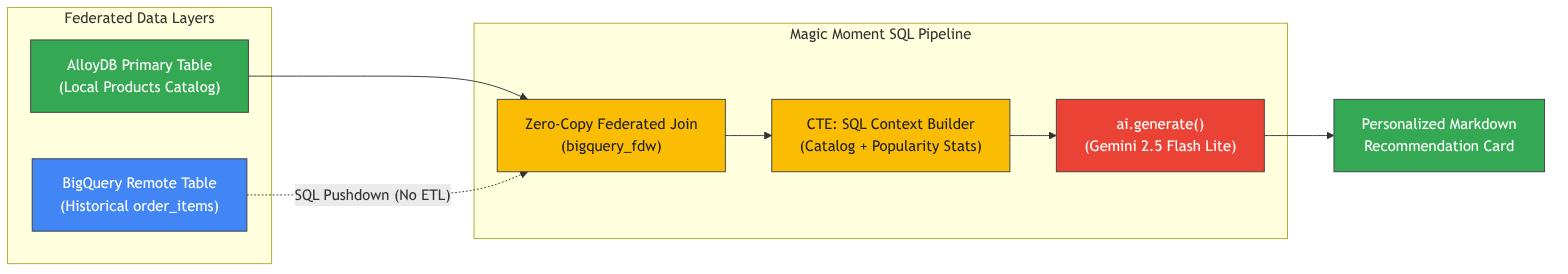</p>


In [ ]:
query_val = "winter coat"

# The SQL query is defined without leading comments to ensure run_query returns a DataFrame
sql_magic = f"""
WITH hybrid_search AS (
  SELECT id, name, brand, retail_price, product_description,
         product_embedding <=> embedding('gemini-embedding-001', '{query_val}')::vector AS distance
  FROM products
  ORDER BY distance ASC
  LIMIT 20
),
enriched_search AS (
  SELECT
    h.*,
    COALESCE(a.order_count, 0) as popularity
  FROM hybrid_search h
  LEFT JOIN (
    SELECT product_id, COUNT(*) as order_count
    FROM bq_ecom.order_items
    GROUP BY 1
  ) a ON h.id = a.product_id
  ORDER BY popularity DESC
  LIMIT 3
),
context_builder AS (
  SELECT string_agg(
    'Product: ' || name || ' (Brand: ' || COALESCE(brand, 'N/A') || ', Price: $' || retail_price || ', Popularity: ' || popularity || ' orders)\nDescription: ' || COALESCE(product_description, 'N/A'),
    '\\n\\n'
  ) AS search_results_context
  FROM enriched_search
)
SELECT
  ai.generate(
    'You are a helpful shopping assistant. Based on the following search results for "' || '{query_val}' || '", which include live popularity data from our BigQuery data lakehouse, write a short, engaging summary recommending the best option for the customer.\\n\\n' || search_results_context,
    model_id => 'gemini-2.5-flash-lite-global'
  ) AS personalized_summary
FROM context_builder;
"""

# Execute the query
magic_result = await run_query(ecom_db_pool, sql_magic)

# Check if result is a DataFrame and extract the summary
if isinstance(magic_result, pd.DataFrame) and not magic_result.empty:
    summary_text = magic_result["personalized_summary"].iloc[0]
    from IPython.display import Markdown, display

    display(
        Markdown(
            f"### Generated personalized recommendation summary:\n\n{summary_text}"
        )
    )
else:
    print("Error: Query did not return a valid DataFrame result.")

### 💡 실습 도전과제 (Challenge 6): 나만의 레이크하우스 페더레이션 AI 개인화 카드 구축

**미션:** 'leather messenger bag'을 검색하고 `bq_ecom.order_items`와 조인하여 총매출액(`ROUND(SUM(o.sale_price), 2) AS total_revenue`)을 계산한 후, `ai.generate()`를 사용해 상위 3개 베스트셀러에 대한 VIP 고객 뉴스레터를 작성하는 다중 CTE 쿼리를 만들어 보세요.

> 💡 **힌트가 필요하신가요?** 도전과제를 해결하다가 막히는 경우, 본 노트북의 맨 마지막에 있는 **도전과제 힌트 및 솔루션 가이드 (Challenge Tips & Hints)** 섹션에서 추천 SQL 쿼리 팁을 확인할 수 있습니다!


In [ ]:
# =====================================================================
# CHALLENGE 6: 나만의 레이크하우스 페더레이션 AI 개인화 카드 구축
# =====================================================================
# 미션: 'leather messenger bag'을 검색하고 `bq_ecom.order_items`와 조인하여 총매출액(`ROUND(SUM(o.sale_price), 2) AS total_revenue`)을 계산한 후, `ai.generate()`를 사용해 상위 3개 베스트셀러에 대한 VIP 고객 뉴스레터를 작성하는 다중 CTE 쿼리를 만들어 보세요.
#
# =====================================================================

sql_challenge_6 = """
-- [여기에 직접 작성한 SQL 쿼리를 입력하세요]
"""

# 아래 주석을 해제(# 제거)한 후 셀을 실행하여 작성한 쿼리 결과를 확인하세요:
# await run_query(sql_challenge_6)


# 축하합니다!! 🎉

**The Operational AI Leap** 실습을 성공적으로 완료하셨습니다!

---

## 핵심 요약 및 핵심 이점

- **운영 안정성 보장** : AI 및 분석 쿼리를 **AlloyDB 읽기 전용 풀(Read Pool)** 과 **BigQuery** 로 오프로드하여, OLTP 고객 트랜잭션이 100% 분리되고 보호됩니다.
- **아키텍처 단순화** : 외부 벡터 DB나 무거운 Python 데이터 파이프라인을 완전히 제거함으로써 인프라 복잡성과 유지보수 비용을 대폭 절감했습니다.
- **실시간 데이터 AI** : ETL 배치 주기를 기다리지 않고 운영 데이터베이스에 상품이 추가되는 즉시 0ms 지연 시간으로 최신 AI 추천에 반영됩니다.

### 다음 단계
- [AlloyDB AI 공식 문서](https://cloud.google.com/alloydb/docs/ai/overview) 살펴보기
- [Google Cloud Architecture Center](https://cloud.google.com/architecture)에서 실시간 및 생성형 AI를 위한 클라우드 네이티브 패턴 학습하기


## 🔍 도전과제 힌트 및 솔루션 가이드

*도전과제 해결에 도움이 꼭 필요한 경우에만 아래 힌트를 확인하세요! 먼저 스스로 SQL 쿼리를 구성하고 테스트해 보아야 Zero-ETL 실습의 학습 효과를 극대화할 수 있습니다.*

---

<details>
<summary><b>👉 여기를 클릭하여 Challenge 1 힌트 확인하기: 실시간 상품 카탈로그 필터링 및 집계</b></summary>
<br>

```sql
SELECT id, name, brand, category, retail_price FROM products WHERE category = 'Apparel & Accessories' ORDER BY retail_price DESC LIMIT 1000;
```

</details>

<details>
<summary><b>👉 여기를 클릭하여 Challenge 2 힌트 확인하기: SQL 내부 임베딩 생성 및 LLM 프롬프팅</b></summary>
<br>

```sql
SELECT name, ai.generate('gemini-model', 'Write a 1-sentence social media ad for this product: ' || name) AS promotional_ad FROM products WHERE category = 'Sunglasses' LIMIT 3;
```

</details>

<details>
<summary><b>👉 여기를 클릭하여 Challenge 3 힌트 확인하기: AI 생성 마케팅 설명 분석 및 키워드 검색</b></summary>
<br>

```sql
SELECT id, name, brand, product_description FROM products WHERE product_description ILIKE '%lightweight%' LIMIT 1000;
```

</details>

<details>
<summary><b>👉 여기를 클릭하여 Challenge 4 힌트 확인하기: Dense Vector 시맨틱 검색 직접 테스트</b></summary>
<br>

```sql
SELECT id, name, brand, (embedding <=> embedding('gemini-embedding-model', 'cozy winter wool sweater')) AS distance FROM products ORDER BY distance ASC LIMIT 1000;
```

</details>

<details>
<summary><b>👉 여기를 클릭하여 Challenge 5 힌트 확인하기: Reciprocal Rank Fusion (RRF) 민감도 튜닝</b></summary>
<br>

`RRF 가중치 계산 CTE에서 `(1.0 / (15 + v.vector_rank))` 또는 `2.0 * (1.0 / (60 + v.vector_rank))`를 사용하여 순위 민감도의 변화를 확인해 보세요!`

</details>

<details>
<summary><b>👉 여기를 클릭하여 Challenge 6 힌트 확인하기: 나만의 레이크하우스 페더레이션 AI 개인화 카드 구축</b></summary>
<br>

`Magic Moment의 4단계 CTE 쿼리에서 `COUNT(o.id)`를 `ROUND(SUM(o.sale_price), 2) AS total_revenue`로 변경하고, LLM 프롬프트를 'Write a VIP promotional newsletter featuring these high-revenue items: ' || ARRAY_AGG(...) 형태로 수정해 보세요!`

</details>
